# ESG Score vs. Financial Performance Analysis

## 1. Problem Definition
This analysis explores the relationship between a company's ESG (Environmental, Social, Governance) score and key financial metrics: Profit Margin, Revenue, Market Cap, and Growth Rate. Target users include investors, corporate sustainability teams, and academic researchers who want to understand whether ESG practices correlate with financial outcomes.

## 2. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('esg_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (11000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [2]:
# Missing values
print("Missing values:\n", df.isnull().sum())

# Statistical summary
df.describe()

Missing values:
 CompanyID               0
CompanyName             0
Industry                0
Region                  0
Year                    0
Revenue                 0
ProfitMargin            0
MarketCap               0
GrowthRate           1000
ESG_Overall             0
ESG_Environmental       0
ESG_Social              0
ESG_Governance          0
CarbonEmissions         0
WaterUsage              0
EnergyConsumption       0
dtype: int64


,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09


## 3. Data Cleaning & Preprocessing
- Drop rows with missing values
- Create ESG category (Low/Medium/High) based on ESG_Overall score tertiles
- Ensure numeric types for financial columns

In [3]:
 # Drop missing values
df_clean = df.dropna()
print(f"Rows after dropping missing: {len(df_clean)}")

# Create ESG category (tertiles)
df_clean['ESG_Category'] = pd.qcut(df_clean['ESG_Overall'], q=3, labels=['Low', 'Medium', 'High'])
df_clean['ESG_Category'].value_counts()

Rows after dropping missing: 10000


ESG_Category
Low       3343
Medium    3343
High      3314
Name: count, dtype: int64

## 4. Analysis Process & Visualizations

### 4.1 ESG Overall Score vs. Profit Margin (Scatter plot by Industry)

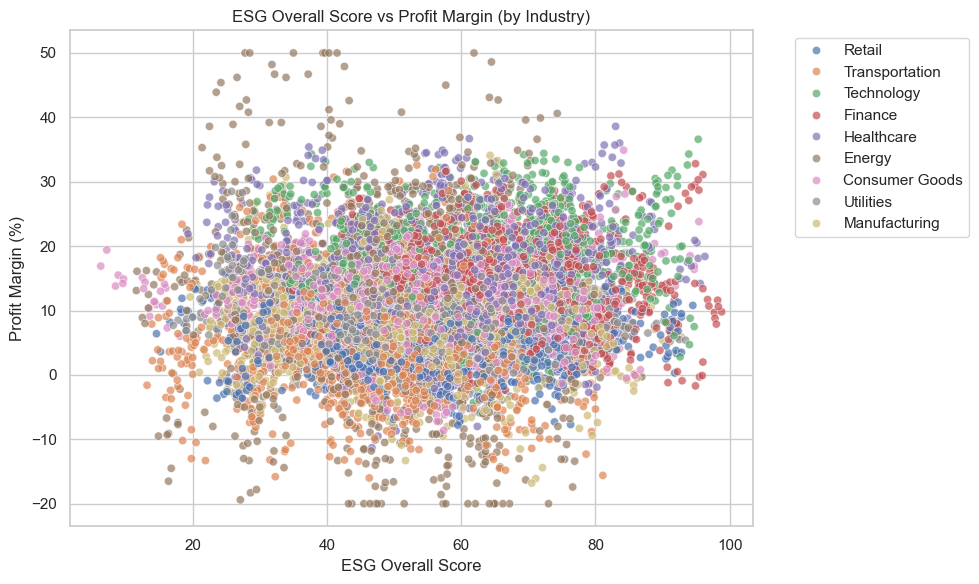

In [4]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='ESG_Overall', y='ProfitMargin', hue='Industry', alpha=0.7)
plt.title('ESG Overall Score vs Profit Margin (by Industry)')
plt.xlabel('ESG Overall Score')
plt.ylabel('Profit Margin (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.2 Average Profit Margin by ESG Category (Bar chart)

C:\Users\fxl66\AppData\Local\Temp\ipykernel_39148\3285962579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_profit, x='ESG_Category', y='ProfitMargin', palette='viridis')


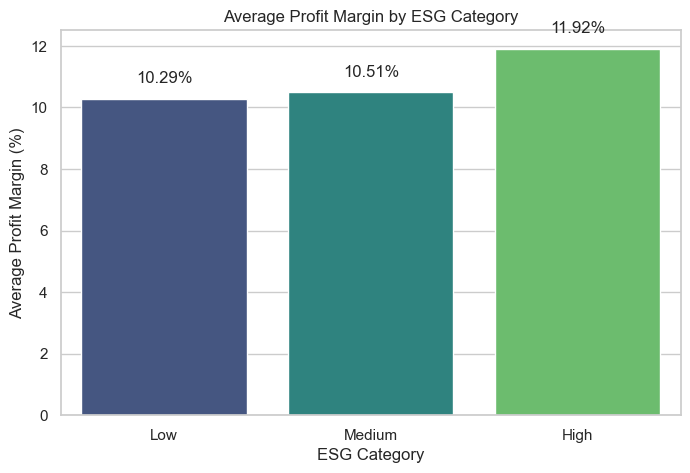

In [5]:
avg_profit = df_clean.groupby('ESG_Category')['ProfitMargin'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=avg_profit, x='ESG_Category', y='ProfitMargin', palette='viridis')
plt.title('Average Profit Margin by ESG Category')
plt.xlabel('ESG Category')
plt.ylabel('Average Profit Margin (%)')

# Add value labels
for i, v in enumerate(avg_profit['ProfitMargin']):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center')
plt.show()

### 4.3 Correlation Matrix (ESG dimensions vs. Financial metrics)

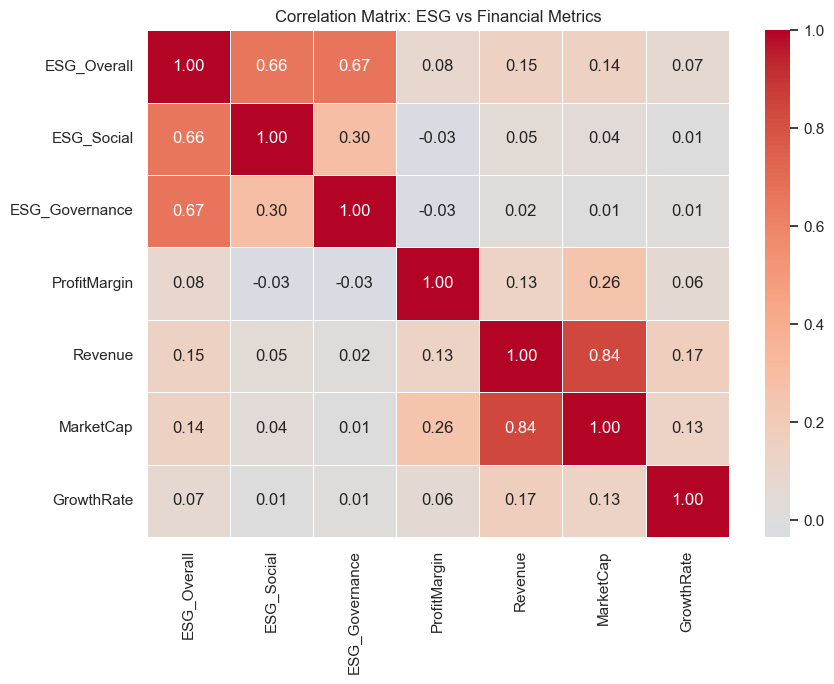

In [6]:
# Select numeric columns
numeric_cols = ['ESG_Overall', 'ESG_Social', 'ESG_Governance', 'ProfitMargin', 'Revenue', 'MarketCap', 'GrowthRate']
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: ESG vs Financial Metrics')
plt.tight_layout()
plt.show()

### 4.4 Industry Comparison: Average ESG Score vs. Average Profit Margin

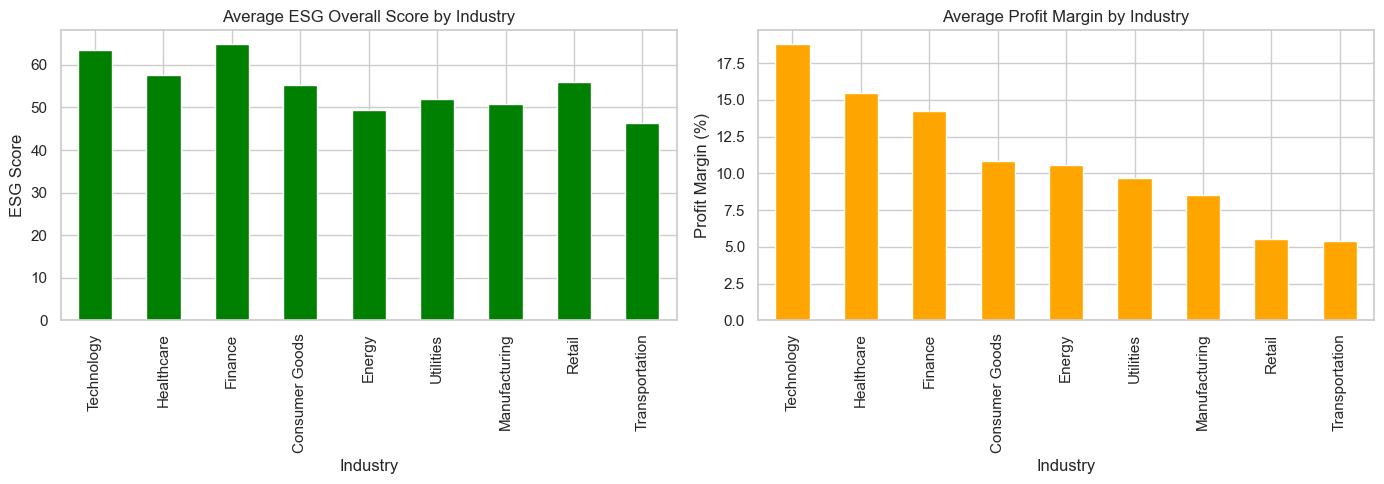

In [7]:
industry_group = df_clean.groupby('Industry')[['ESG_Overall', 'ProfitMargin']].mean().sort_values('ProfitMargin', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14,5))
industry_group['ESG_Overall'].plot(kind='bar', ax=ax[0], color='green')
ax[0].set_title('Average ESG Overall Score by Industry')
ax[0].set_ylabel('ESG Score')
industry_group['ProfitMargin'].plot(kind='bar', ax=ax[1], color='orange')
ax[1].set_title('Average Profit Margin by Industry')
ax[1].set_ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

## 5. Key Insights & Conclusions
1. The correlation between ESG Overall score and Profit Margin is very weak (≈0.09), suggesting that high ESG scores do not guarantee higher profitability.
2. Average profit margin across ESG categories (Low/Medium/High) shows only a small difference – High ESG group slightly outperforms Low group.
3. Revenue and Market Cap are strongly correlated (0.84), as expected.
4. Industries differ significantly in both ESG scores and profit margins. For example, Finance and Technology have high ESG scores but not necessarily the highest margins.

These findings imply that ESG should be considered as a non-financial risk indicator rather than a direct predictor of short-term profits.


## 6. Limitations & Future Improvements
- Cross-sectional data: cannot infer causality.
- Missing control variables (firm size, leverage, R&D spending).
- ESG scores vary across rating agencies; results may not generalize.
- Future work: use panel data, add regression with industry and size fixed effects, and perform statistical significance tests (t-test/ANOVA).